Step 1: Data Loading & Initial Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset directly from GitHub (Raw link)
url = 'https://raw.githubusercontent.com/Ketan-Chavda/Superstore_Sales_Profit_Discount/main/Sample%20-%20Superstore.csv'
df = pd.read_csv(url, encoding='windows-1252')

# Display basic info
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Step 2: Data Cleaning

In [6]:
# 1. Convert Date columns to actual datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 2. Extract Year and Month for Time Series Analysis
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month_name()

# 3. Check for missing values
print("Missing Values:\n", df.isnull().sum())

# 4. Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Order Year       0
Order Month      0
dtype: int64
Duplicate rows: 0


Step 3: Exploratory Data Analysis (EDA)

A. Sales & Profit by Category

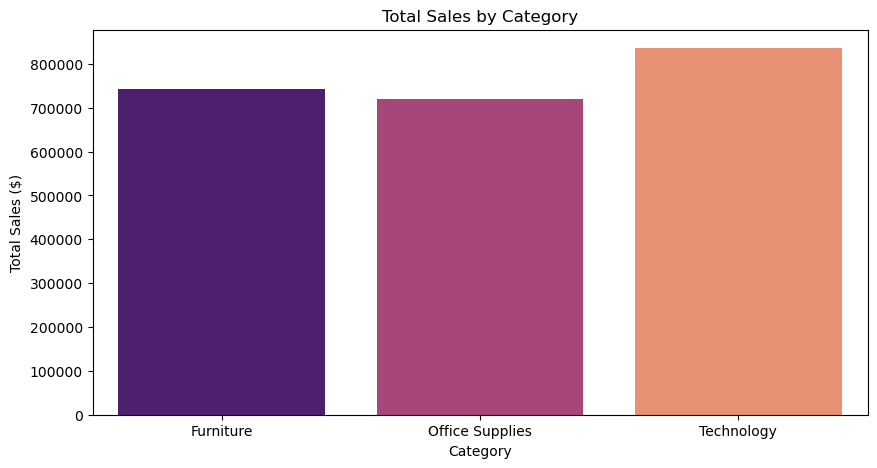

In [11]:
category_analysis = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(10,5))
# Assign 'Category' to hue and set legend=False to follow the new standard
sns.barplot(data=category_analysis, x='Category', y='Sales', hue='Category', palette='magma', legend=False)

plt.title('Total Sales by Category')
plt.ylabel('Total Sales ($)')
plt.show()

B. Monthly Sales Trend (To see seasonality)

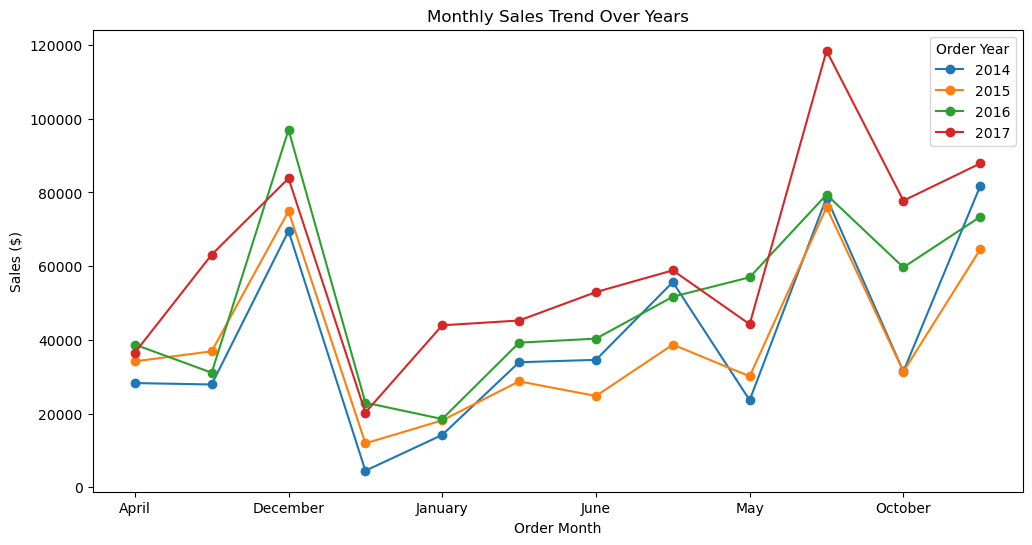

In [9]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
# Pivot for easier plotting
pivot_sales = monthly_sales.pivot(index="Order Month", columns="Order Year", values="Sales")

pivot_sales.plot(kind='line', figsize=(12,6), marker='o')
plt.title('Monthly Sales Trend Over Years')
plt.ylabel('Sales ($)')
plt.show()

Step 4: Prepare for SQL and Power BI

In [12]:
# Export cleaned data for SQL/Power BI use
df.to_csv('Cleaned_Superstore_Data.csv', index=False)

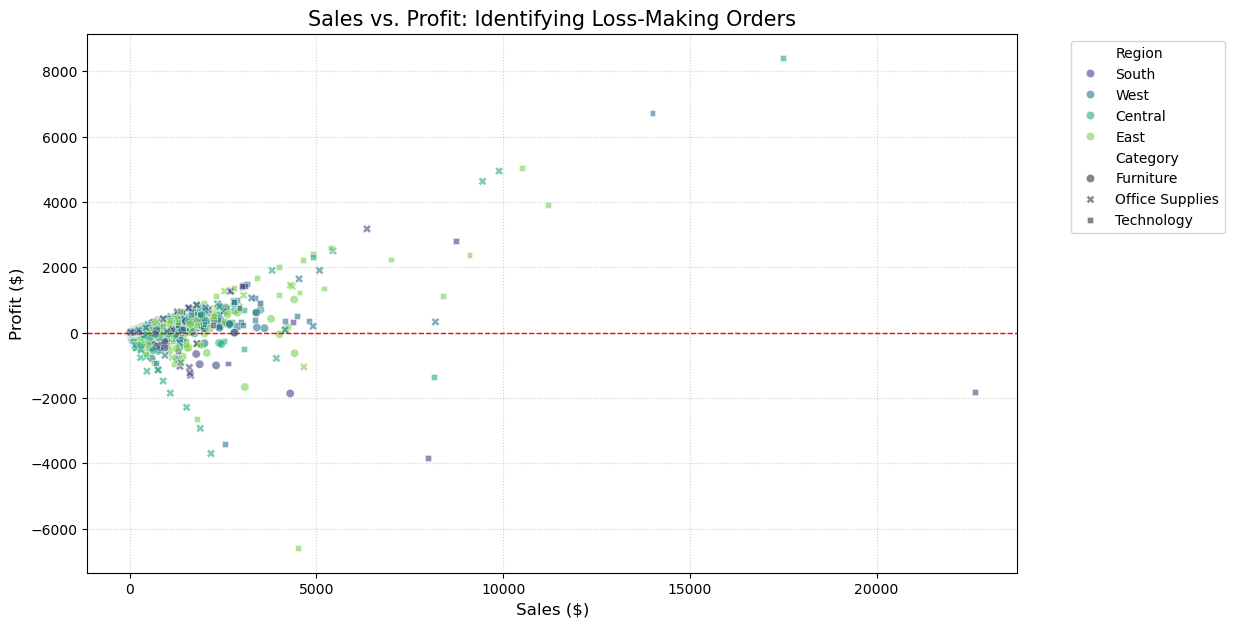

In [13]:
plt.figure(figsize=(12, 7))

# Create the scatter plot
sns.scatterplot(
    data=df, 
    x='Sales', 
    y='Profit', 
    hue='Region',      # Colors points by Region
    style='Category',  # Different shapes for Category
    alpha=0.6,         # Makes points slightly transparent
    palette='viridis'
)

# Add a horizontal line at 0 Profit to clearly see losses
plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.title('Sales vs. Profit: Identifying Loss-Making Orders', fontsize=15)
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside

plt.show()